# **Downloading Dataset to Input Folder**
It should store dataset in kaggle's input folder

In [1]:
import kagglehub

path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/zalando-research/fashionmnist


# **Importing Libraries**

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# **Extracting Dataset**

In [3]:
import os
DATA_DIR = "/kaggle/input/datasets/zalando-research/fashionmnist"

train_path = os.path.join(DATA_DIR, "fashion-mnist_train.csv")
test_path = os.path.join(DATA_DIR, "fashion-mnist_test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# **Converting dataframe in matrix form**
Because we don't need a pandas dataframe with column names

In [4]:
X = train_df.drop("label", axis=1).values
y = train_df["label"].values
X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

# **Checking their shape**

In [5]:
print("X:", X.shape)
print("y:", y.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X: (60000, 784)
y: (60000,)
X_test: (10000, 784)
y_test: (10000,)


# **Normalizing**
As each value is a pixel value which ranges between 0 to 255, so we are dividing each by 255 to make it in 0 to 1 form

In [6]:
X = X.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# **Flattening**
Converting 24*24 image matrix to 784 row vector using reshape function. -1 in first perimeter means that function will decide how many number of samples

In [7]:
X = X.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

In [8]:
print("Training shape:", X.shape)
print("Test shape:", X_test.shape)

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Training shape: (60000, 784)
Test shape: (10000, 784)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


# **Splitting**
Training and testing data was already splitted. We needed to split training and validation dataset, for that we used random splitting and keeping 80% of training and 20% of validation data. We used **stratify** to equally split each category. Even though, there wasn't much class imabalance issue, but using it seems better

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 48000
Validation samples: 12000
Test samples: 10000


In [11]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [12]:
def show_distribution(y, name):
    counts = np.bincount(y, minlength=10)

    distribution = pd.DataFrame({
        "Class ID": range(10),
        "Class": class_names,
        "Count": counts,
        "Percentage": counts / len(y) * 100
    })

    print(f"\n{name}")
    display(distribution)

In [13]:
show_distribution(y_train, "Training Set")
show_distribution(y_val, "Validation Set")
show_distribution(y_test, "Test Set")


Training Set


,Class ID,Class,Count,Percentage
0,0,T-shirt/top,4800,10.0
1,1,Trouser,4800,10.0
2,2,Pullover,4800,10.0
3,3,Dress,4800,10.0
4,4,Coat,4800,10.0
5,5,Sandal,4800,10.0
6,6,Shirt,4800,10.0
7,7,Sneaker,4800,10.0
8,8,Bag,4800,10.0
9,9,Ankle boot,4800,10.0



Validation Set


,Class ID,Class,Count,Percentage
0,0,T-shirt/top,1200,10.0
1,1,Trouser,1200,10.0
2,2,Pullover,1200,10.0
3,3,Dress,1200,10.0
4,4,Coat,1200,10.0
5,5,Sandal,1200,10.0
6,6,Shirt,1200,10.0
7,7,Sneaker,1200,10.0
8,8,Bag,1200,10.0
9,9,Ankle boot,1200,10.0



Test Set


,Class ID,Class,Count,Percentage
0,0,T-shirt/top,1000,10.0
1,1,Trouser,1000,10.0
2,2,Pullover,1000,10.0
3,3,Dress,1000,10.0
4,4,Coat,1000,10.0
5,5,Sandal,1000,10.0
6,6,Shirt,1000,10.0
7,7,Sneaker,1000,10.0
8,8,Bag,1000,10.0
9,9,Ankle boot,1000,10.0


# **Testing a sample**

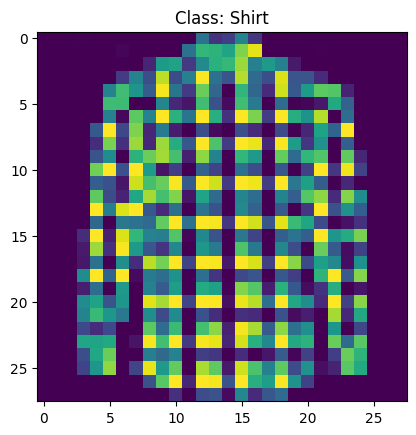

In [14]:
plt.imshow(X_train[0].reshape(28, 28))
plt.title(f"Class: {class_names[y_train[0]]}")

plt.show()

# **PART 1**

# **Initializing Helping Functions for our MLP**

In [15]:
def relu(z):
    return np.maximum(0, z)

In [16]:
def relu_derivative(z):
    return (z > 0).astype(np.float32)

In [17]:
def softmax(z):
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [18]:
def one_hot(y, num_classes=10):
    result = np.zeros((len(y), num_classes), dtype=np.float32)
    result[np.arange(len(y)), y] = 1.0
    return result

In [19]:
def cross_entropy(y_true, y_pred):
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)

    return -np.mean(
        np.sum(y_true * np.log(y_pred), axis=1)
    )

# **Parameter Initialization**
We used **He Normal Weight initialization** technique, because in ReLU it turns all negative inputs into zero. Standard or zero initializations can cause gradients to vanish. 

In [20]:
def initialize_parameters(seed=42):
    rng = np.random.default_rng(seed)

    W1 = rng.standard_normal((784, 64)).astype(np.float32)
    W1 *= np.sqrt(2.0 / 784)

    b1 = np.zeros((1, 64), dtype=np.float32)

    W2 = rng.standard_normal((64, 10)).astype(np.float32)
    W2 *= np.sqrt(2.0 / 64)

    b2 = np.zeros((1, 10), dtype=np.float32)

    return W1, b1, W2, b2

# **Building the feed forward function**
We just taking 2 layers one hidden and one output. So it will just take the dot product of Input vector and weight vector. **@** is used so we don't need to take a transpose.  
We are returning the final output plus a cache dictionary to reuse the intermediate values for backpropagation


In [21]:
def forward(X, W1, b1, W2, b2):

    # First layer
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    # Output layer
    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)

    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return A2, cache

In [22]:
def backward(X, y_onehot, cache, W2):

    Z1 = cache["Z1"]
    A1 = cache["A1"]
    A2 = cache["A2"]

    m = X.shape[0]

    # Output layer gradient
    dZ2 = (A2 - y_onehot) / m

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Hidden layer
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    gradients = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return gradients

In [23]:
def update_parameters(W1, b1, W2, b2, gradients, learning_rate):

    W1 -= learning_rate * gradients["dW1"]
    b1 -= learning_rate * gradients["db1"]

    W2 -= learning_rate * gradients["dW2"]
    b2 -= learning_rate * gradients["db2"]

    return W1, b1, W2, b2

In [24]:
def accuracy(y_true, y_pred):

    predictions = np.argmax(y_pred, axis=1)

    return np.mean(predictions == y_true)

In [25]:
NUM_SAMPLES = 5000
EPOCHS = 20
BATCH_SIZE = 128
LEARNING_RATE = 0.1

X_subset = X_train[:NUM_SAMPLES]
y_subset = y_train[:NUM_SAMPLES]

y_subset_onehot = one_hot(y_subset)

W1, b1, W2, b2 = initialize_parameters(42)

loss_history = []

rng = np.random.default_rng(42)

for epoch in range(EPOCHS):

    # Shuffle training data
    indices = rng.permutation(NUM_SAMPLES)

    X_shuffled = X_subset[indices]
    y_shuffled = y_subset_onehot[indices]

    epoch_loss = 0.0
    num_batches = 0

    for start in range(0, NUM_SAMPLES, BATCH_SIZE):

        end = start + BATCH_SIZE

        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        # Forward
        predictions, cache = forward(
            X_batch,
            W1, b1,
            W2, b2
        )

        loss = cross_entropy(
            y_batch,
            predictions
        )

        # Backward
        gradients = backward(
            X_batch,
            y_batch,
            cache,
            W2
        )

        # Update
        W1, b1, W2, b2 = update_parameters(
            W1, b1,
            W2, b2,
            gradients,
            LEARNING_RATE
        )

        epoch_loss += loss
        num_batches += 1

    epoch_loss /= num_batches
    loss_history.append(epoch_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} "
        f"- Loss: {epoch_loss:.4f}"
    )

Epoch 01/20 - Loss: 1.3069
Epoch 02/20 - Loss: 0.8413
Epoch 03/20 - Loss: 0.7516
Epoch 04/20 - Loss: 0.6585
Epoch 05/20 - Loss: 0.6241
Epoch 06/20 - Loss: 0.5850
Epoch 07/20 - Loss: 0.5547
Epoch 08/20 - Loss: 0.5471
Epoch 09/20 - Loss: 0.5191
Epoch 10/20 - Loss: 0.4961
Epoch 11/20 - Loss: 0.4938
Epoch 12/20 - Loss: 0.4965
Epoch 13/20 - Loss: 0.4547
Epoch 14/20 - Loss: 0.4715
Epoch 15/20 - Loss: 0.4601
Epoch 16/20 - Loss: 0.4343
Epoch 17/20 - Loss: 0.4208
Epoch 18/20 - Loss: 0.4229
Epoch 19/20 - Loss: 0.4496
Epoch 20/20 - Loss: 0.4788


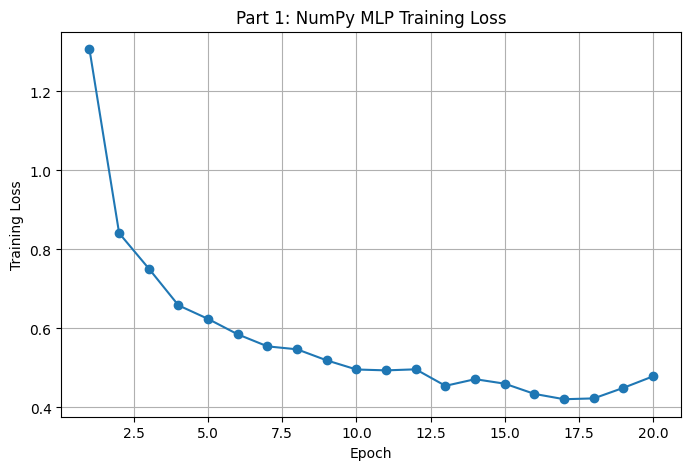

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Part 1: NumPy MLP Training Loss")
plt.grid(True)

plt.show()

# **PART 2**

In [27]:
SEED=42
import torch
import torch.nn as nn

torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [28]:
BATCH_SIZE_CHECK = 64

X_batch = X_train[:BATCH_SIZE_CHECK]
y_batch = y_train[:BATCH_SIZE_CHECK]

X_batch_np = X_batch.astype(np.float32)

y_batch_onehot = one_hot(
    y_batch
)

In [29]:
W1_np, b1_np, W2_np, b2_np = initialize_parameters(SEED)

pred_np, cache_np = forward(
    X_batch_np,
    W1_np,
    b1_np,
    W2_np,
    b2_np
)

loss_np = cross_entropy(
    y_batch_onehot,
    pred_np
)

grads_np = backward(
    X_batch_np,
    y_batch_onehot,
    cache_np,
    W2_np
)

print("NumPy loss:", loss_np)

NumPy loss: 2.4144738


In [30]:
W1_np, b1_np, W2_np, b2_np = initialize_parameters(SEED)

pred_np, cache_np = forward(
    X_batch_np,
    W1_np,
    b1_np,
    W2_np,
    b2_np
)

loss_np = cross_entropy(
    y_batch_onehot,
    pred_np
)

grads_np = backward(
    X_batch_np,
    y_batch_onehot,
    cache_np,
    W2_np
)

print("NumPy loss:", loss_np)

NumPy loss: 2.4144738


In [31]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [32]:
nn.CrossEntropyLoss()

CrossEntropyLoss()

In [33]:
model = MLP().to(device)

with torch.no_grad():

    model.fc1.weight.copy_(
        torch.tensor(W1_np.T)
    )

    model.fc1.bias.copy_(
        torch.tensor(b1_np.flatten())
    )

    model.fc2.weight.copy_(
        torch.tensor(W2_np.T)
    )

    model.fc2.bias.copy_(
        torch.tensor(b2_np.flatten())
    )

In [34]:
criterion = nn.CrossEntropyLoss()

X_torch = torch.tensor(
    X_batch_np,
    dtype=torch.float32,
    device=device
)

y_torch = torch.tensor(
    y_batch,
    dtype=torch.long,
    device=device
)

model.zero_grad()

logits = model(X_torch)

loss_torch = criterion(
    logits,
    y_torch
)

loss_torch.backward()

print("PyTorch loss:", loss_torch.item())

PyTorch loss: 2.41447377204895


In [35]:
dW1_torch = (
    model.fc1.weight.grad
    .detach()
    .cpu()
    .numpy()
    .T
)

dW2_torch = (
    model.fc2.weight.grad
    .detach()
    .cpu()
    .numpy()
    .T
)

diff_W1 = np.max(
    np.abs(grads_np["dW1"] - dW1_torch)
)

diff_W2 = np.max(
    np.abs(grads_np["dW2"] - dW2_torch)
)

print(f"Maximum absolute difference for W1: {diff_W1:.10e}")
print(f"Maximum absolute difference for W2: {diff_W2:.10e}")

Maximum absolute difference for W1: 2.2351741791e-08
Maximum absolute difference for W2: 4.4703483582e-08


In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import time

In [37]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

print("Training:", X_train_t.shape)
print("Validation:", X_val_t.shape)


Training: torch.Size([48000, 784])
Validation: torch.Size([12000, 784])


In [38]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train_t,
    y_train_t
)

val_dataset = TensorDataset(
    X_val_t,
    y_val_t
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

In [39]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train_t,
    y_train_t
)

val_dataset = TensorDataset(
    X_val_t,
    y_val_t
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

In [40]:
class ActivationMLP(nn.Module):

    def __init__(self, activation):
        super().__init__()

        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

        self.activation = activation

    def forward(self, x):

        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)

        return x

In [41]:
activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU(),
    "Leaky ReLU": nn.LeakyReLU(negative_slope=0.01)
}

print(list(activations.keys()))

['Sigmoid', 'Tanh', 'ReLU', 'Leaky ReLU']


In [42]:
def evaluate_model(model, loader, device):

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)

            loss = criterion(
                logits,
                y_batch
            )

            total_loss += loss.item() * len(y_batch)

            predictions = torch.argmax(
                logits,
                dim=1
            )

            correct += (
                predictions == y_batch
            ).sum().item()

            total += len(y_batch)

    return (
        total_loss / total,
        correct / total
    )

In [43]:
def train_activation_model(
    activation,
    epochs=20,
    learning_rate=0.001
):

    # Reproducible initialization
    torch.manual_seed(SEED)

    model = ActivationMLP(activation).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": []
    }

    first_layer_gradient_epoch1 = None
    first_layer_gradient_final = None

    for epoch in range(epochs):

        model.train()

        # Recreate loader with identical ordering
        generator = torch.Generator()
        generator.manual_seed(SEED + epoch)

        train_loader_epoch = DataLoader(
            train_dataset,
            batch_size=128,
            shuffle=True,
            generator=generator
        )

        total_loss = 0.0
        total_samples = 0

        gradient_recorded = False

        for X_batch, y_batch in train_loader_epoch:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(X_batch)

            loss = criterion(
                logits,
                y_batch
            )

            loss.backward()

            # Record first hidden-layer gradient
            # during the first batch of epoch 1
            if epoch == 0 and not gradient_recorded:

                first_layer_gradient_epoch1 = (
                    model.fc1.weight.grad
                    .detach()
                    .abs()
                    .mean()
                    .item()
                )

                gradient_recorded = True

            optimizer.step()

            total_loss += (
                loss.item() * len(y_batch)
            )

            total_samples += len(y_batch)

        train_loss = total_loss / total_samples

        val_loss, val_accuracy = evaluate_model(
            model,
            val_loader,
            device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        # Save final epoch gradient
        if epoch == epochs - 1:

            first_layer_gradient_final = (
                model.fc1.weight.grad
                .detach()
                .abs()
                .mean()
                .item()
            )

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

    return (
        model,
        history,
        first_layer_gradient_epoch1,
        first_layer_gradient_final
    )

In [44]:
activation_results = {}

for name, activation in activations.items():

    print("\n" + "=" * 70)
    print(f"Training: {name}")
    print("=" * 70)

    model, history, grad_epoch1, grad_final = (
        train_activation_model(
            activation=activation,
            epochs=20,
            learning_rate=0.001
        )
    )

    activation_results[name] = {
        "model": model,
        "history": history,
        "gradient_epoch1": grad_epoch1,
        "gradient_final": grad_final
    }


Training: Sigmoid
Epoch 01/20 | Train Loss: 0.9184 | Val Loss: 0.5198 | Val Acc: 0.8138
Epoch 02/20 | Train Loss: 0.4612 | Val Loss: 0.4247 | Val Acc: 0.8464
Epoch 03/20 | Train Loss: 0.4016 | Val Loss: 0.3893 | Val Acc: 0.8609
Epoch 04/20 | Train Loss: 0.3700 | Val Loss: 0.3722 | Val Acc: 0.8664
Epoch 05/20 | Train Loss: 0.3509 | Val Loss: 0.3670 | Val Acc: 0.8667
Epoch 06/20 | Train Loss: 0.3326 | Val Loss: 0.3432 | Val Acc: 0.8762
Epoch 07/20 | Train Loss: 0.3179 | Val Loss: 0.3487 | Val Acc: 0.8728
Epoch 08/20 | Train Loss: 0.3051 | Val Loss: 0.3499 | Val Acc: 0.8708
Epoch 09/20 | Train Loss: 0.2955 | Val Loss: 0.3248 | Val Acc: 0.8836
Epoch 10/20 | Train Loss: 0.2854 | Val Loss: 0.3309 | Val Acc: 0.8773
Epoch 11/20 | Train Loss: 0.2773 | Val Loss: 0.3275 | Val Acc: 0.8824
Epoch 12/20 | Train Loss: 0.2670 | Val Loss: 0.3243 | Val Acc: 0.8824
Epoch 13/20 | Train Loss: 0.2598 | Val Loss: 0.3118 | Val Acc: 0.8879
Epoch 14/20 | Train Loss: 0.2507 | Val Loss: 0.3156 | Val Acc: 0.8865
E

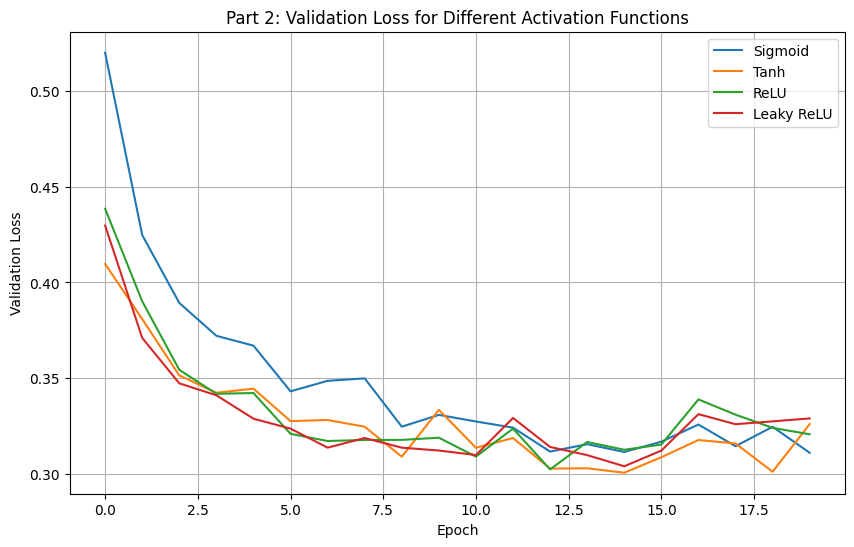

In [45]:
plt.figure(figsize=(10, 6))

for name in activations:

    plt.plot(
        activation_results[name]["history"]["val_loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Part 2: Validation Loss for Different Activation Functions")
plt.legend()
plt.grid(True)

plt.show()

In [46]:
activation_summary = []

for name in activations:

    history = activation_results[name]["history"]

    activation_summary.append({
        "Activation": name,
        "Final Validation Loss": history["val_loss"][-1],
        "Final Validation Accuracy": history["val_accuracy"][-1],
        "Epoch 1 Mean |Gradient|": activation_results[name]["gradient_epoch1"],
        "Final Mean |Gradient|": activation_results[name]["gradient_final"]
    })

activation_summary_df = pd.DataFrame(
    activation_summary
)

display(activation_summary_df)

,Activation,Final Validation Loss,Final Validation Accuracy,Epoch 1 Mean |Gradient|,Final Mean |Gradient|
0,Sigmoid,0.311158,0.890333,0.000070,0.000261
1,Tanh,0.326125,0.888083,0.000889,0.000575
2,ReLU,0.320796,0.894083,0.000358,0.000484
3,Leaky ReLU,0.329063,0.895083,0.000359,0.000519


In [47]:
print("Sigmoid")
print(
    "Epoch 1:",
    activation_results["Sigmoid"]["gradient_epoch1"]
)
print(
    "Final:",
    activation_results["Sigmoid"]["gradient_final"]
)

print("\nReLU")
print(
    "Epoch 1:",
    activation_results["ReLU"]["gradient_epoch1"]
)
print(
    "Final:",
    activation_results["ReLU"]["gradient_final"]
)

Sigmoid
Epoch 1: 7.017080497462302e-05
Final: 0.0002608329232316464

ReLU
Epoch 1: 0.0003575267328415066
Final: 0.00048390281153842807


In [48]:
relu_model = activation_results["ReLU"]["model"]

relu_model.eval()

X_val_batch, y_val_batch = next(
    iter(val_loader)
)

X_val_batch = X_val_batch.to(device)

with torch.no_grad():

    hidden_output = torch.relu(
        relu_model.fc1(X_val_batch)
    )

print("Hidden output shape:", hidden_output.shape)

Hidden output shape: torch.Size([128, 256])


In [49]:
zero_for_every_sample = (
    hidden_output == 0
).all(dim=0)

dead_units = zero_for_every_sample.sum().item()

total_hidden_units = hidden_output.shape[1]

dead_percentage = (
    dead_units / total_hidden_units
) * 100

print("Dead hidden units:", dead_units)
print("Total hidden units:", total_hidden_units)
print(f"Dead-unit percentage: {dead_percentage:.2f}%")

Dead hidden units: 31
Total hidden units: 256
Dead-unit percentage: 12.11%


# **PART 3**

In [50]:
epochs = 20
lr = 0.001
batch_size = 128
seed_value = 42

torch.manual_seed(seed_value)
np.random.seed(seed_value)

In [51]:
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

test_dataset = TensorDataset(X_test_t, y_test_t)

test_loader = DataLoader(test_dataset, batch_size, shuffle=False)

print("Test samples: ", len(test_dataset))

Test samples:  10000


In [52]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [53]:
def evaluate_test_accuracy(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            predictions = torch.argmax(logits, dim=1)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    return correct / total

In [54]:
def train_classifier(loss_name):
    torch.manual_seed(seed_value)
    model = MLP().to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    if loss_name == "Cross-Entropy":
        criterion = nn.CrossEntropyLoss()

    elif loss_name == "MSE":
        criterion = nn.MSELoss()

    else:
        raise ValueError("loss_name must be 'Cross-Entropy' or 'MSE'")

    history = {"train_loss": [], "val_loss": [], "val_accuracy": []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_samples = 0

        generator = torch.Generator().manual_seed(seed_value + epoch)

        epoch_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator)

        for X_batch, y_batch in epoch_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(X_batch)

            if loss_name == "Cross-Entropy":
                loss = criterion(logits, y_batch)

            else:
                probabilities = torch.softmax(logits, dim=1)
                targets = torch.nn.functional.one_hot(y_batch, num_classes=10).float()

                loss = criterion(probabilities, targets)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * y_batch.size(0)
            total_samples += y_batch.size(0)

        train_loss = total_loss / total_samples

        # Validation loss and accuracy
        model.eval()
        val_total_loss = 0.0
        val_total_samples = 0
        val_correct = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                logits = model(X_batch)

                if loss_name == "Cross-Entropy":
                    val_loss_batch = criterion(logits, y_batch)

                else:
                    probabilities = torch.softmax(logits, dim=1)
                    targets = torch.nn.functional.one_hot(y_batch, num_classes=10).float()

                    val_loss_batch = criterion(probabilities, targets)

                val_total_loss += (val_loss_batch.item() * y_batch.size(0))

                val_total_samples += y_batch.size(0)

                val_correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()

        val_loss = val_total_loss / val_total_samples
        val_accuracy = val_correct / val_total_samples

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(f"{loss_name:14s} | "f"Epoch {epoch + 1:02d}/{epochs} | "f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "f"Val Acc: {val_accuracy:.4f}")

    test_accuracy = evaluate_test_accuracy(model)

    return model, history, test_accuracy

In [55]:
ce_model, ce_history, ce_test_accuracy = train_classifier("Cross-Entropy")

mse_model, mse_history, mse_test_accuracy = train_classifier("MSE")

print(f"Categorical Cross-Entropy: {ce_test_accuracy:.4%}")
print(f"Mean Squared Error: {mse_test_accuracy:.4%}")
print(f"Difference (CE - MSE): " f"{(ce_test_accuracy - mse_test_accuracy):.4%}")

Cross-Entropy  | Epoch 01/20 | Train Loss: 0.5984 | Val Loss: 0.4384 | Val Acc: 0.8437
Cross-Entropy  | Epoch 02/20 | Train Loss: 0.4121 | Val Loss: 0.3902 | Val Acc: 0.8540
Cross-Entropy  | Epoch 03/20 | Train Loss: 0.3682 | Val Loss: 0.3544 | Val Acc: 0.8727
Cross-Entropy  | Epoch 04/20 | Train Loss: 0.3368 | Val Loss: 0.3419 | Val Acc: 0.8754
Cross-Entropy  | Epoch 05/20 | Train Loss: 0.3177 | Val Loss: 0.3423 | Val Acc: 0.8739
Cross-Entropy  | Epoch 06/20 | Train Loss: 0.3012 | Val Loss: 0.3210 | Val Acc: 0.8811
Cross-Entropy  | Epoch 07/20 | Train Loss: 0.2856 | Val Loss: 0.3173 | Val Acc: 0.8822
Cross-Entropy  | Epoch 08/20 | Train Loss: 0.2725 | Val Loss: 0.3178 | Val Acc: 0.8802
Cross-Entropy  | Epoch 09/20 | Train Loss: 0.2605 | Val Loss: 0.3179 | Val Acc: 0.8838
Cross-Entropy  | Epoch 10/20 | Train Loss: 0.2507 | Val Loss: 0.3190 | Val Acc: 0.8805
Cross-Entropy  | Epoch 11/20 | Train Loss: 0.2416 | Val Loss: 0.3092 | Val Acc: 0.8898
Cross-Entropy  | Epoch 12/20 | Train Loss: 

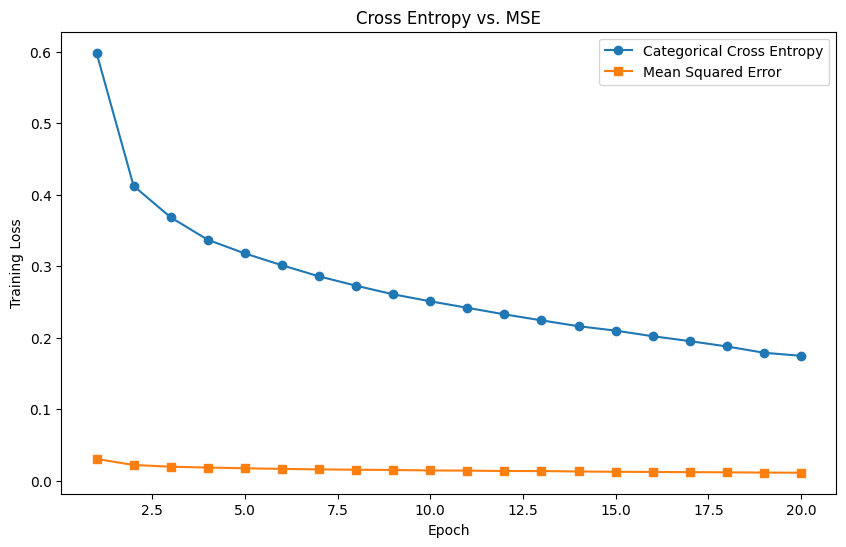

In [56]:
plt.figure(figsize=(10, 6))

epochs = range(1, epochs+1)

plt.plot(epochs, ce_history["train_loss"], marker='o', label="Categorical Cross Entropy")

plt.plot(epochs, mse_history["train_loss"], marker='s', label="Mean Squared Error")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Cross Entropy vs. MSE")
plt.legend()
plt.show()

**Tabular Regression Experiment**

In [57]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [58]:
X_reg, y_reg = load_diabetes(return_X_y=True)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_scalar = StandardScaler()

X_reg_train = reg_scalar.fit_transform(X_reg_train)
X_reg_test = reg_scalar.fit_transform(X_reg_test)

X_reg_train_t = torch.tensor(X_reg_train, dtype=torch.float32)
y_reg_train_t = torch.tensor(y_reg_train, dtype=torch.float32).view(-1, 1)
X_reg_test_t = torch.tensor(X_reg_test, dtype=torch.float32)
y_reg_test_t = torch.tensor(y_reg_test, dtype=torch.float32).view(-1, 1)

reg_train_dataset = TensorDataset(X_reg_train_t, y_reg_train_t)
reg_train_loader = DataLoader(reg_train_dataset, batch_size=32, shuffle=True, generator=torch.Generator().manual_seed(42))

print("Training samples: ", len(X_reg_train))
print("Testing samples: ", len(X_reg_test))
print("Input features: ", X_reg_train.shape[1])

Training samples:  353
Testing samples:  89
Input features:  10


In [59]:
class RegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(nn.Linear(input_dim, 32), nn.ReLU(), nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1))

    def forward(self, x):
        return self.network(x)


torch.manual_seed(42)

reg_model = RegressionMLP(input_dim=X_reg_train.shape[1]).to(device)

reg_criterion = nn.MSELoss()

reg_optimizer = optim.Adam(reg_model.parameters(), lr=0.001)

REG_EPOCHS = 100
reg_history = []

for epoch in range(REG_EPOCHS):

    reg_model.train()

    total_loss = 0.0
    total_samples = 0

    for X_batch, y_batch in reg_train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        reg_optimizer.zero_grad()

        predictions = reg_model(X_batch)

        loss = reg_criterion(predictions, y_batch)

        loss.backward()
        reg_optimizer.step()

        total_loss += loss.item() * y_batch.size(0)
        total_samples += y_batch.size(0)

    epoch_loss = total_loss / total_samples
    reg_history.append(epoch_loss)

reg_model.eval()

with torch.no_grad():
    reg_predictions = (
        reg_model(X_reg_test_t.to(device)).cpu().numpy().ravel())

reg_mse = mean_squared_error(y_reg_test, reg_predictions)

reg_rmse = np.sqrt(reg_mse)

reg_mae = mean_absolute_error(y_reg_test, reg_predictions)

print(f"Test MSE:  {reg_mse:.4f}")
print(f"Test RMSE: {reg_rmse:.4f}")
print(f"Test MAE:  {reg_mae:.4f}")

Test MSE:  3203.5736
Test RMSE: 56.6001
Test MAE:  45.0928


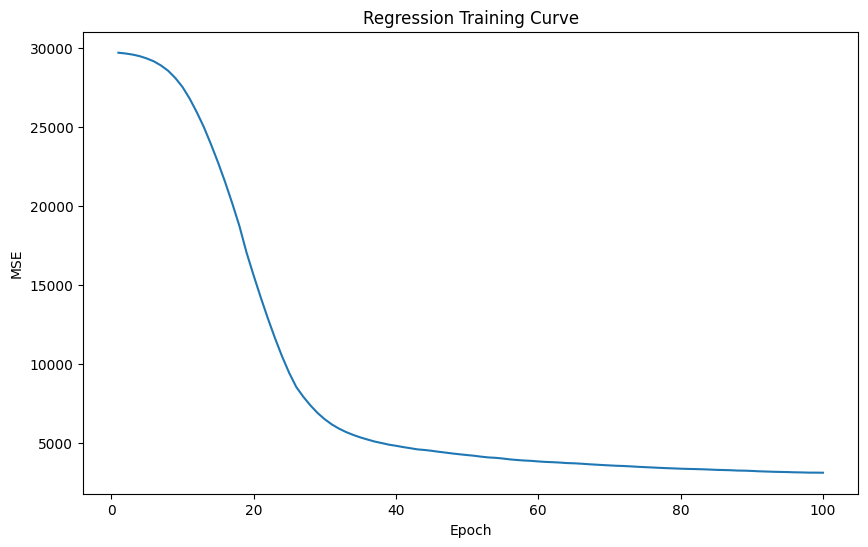

In [60]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, REG_EPOCHS + 1), reg_history, label="Training MSE")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Regression Training Curve")
plt.show()

**Comment**

Cross-entropy generally converges faster for classification because it is designed for probabilistic class prediction. With softmax followed by cross-entropy, the gradient with respect to the logits provides a direct learning signal based on the difference between the predicted probabilities and the one-hot target.

With MSE, the error is measured between the predicted probabilities and the one-hot targets, and its gradient also passes through the softmax derivative. When the softmax becomes saturated, that derivative can become very small, reducing the learning signal and slowing optimization. Therefore, categorical cross-entropy is usually a better-matched loss for classification, while MSE is a natural loss for continuous regression targets.

**Conclusion:** the loss function should match the output or task: cross-entropy for the classification experiment and MSE for the continuous regression experiment.

## **Part 4**

In [61]:
import time
import pandas as pd

EPOCHS = 20
BATCH_SIZE = 128
LR = 0.001
TARGET_ACCURACY = 0.85
SEED = 42

In [62]:
def train_optimizer_model(optimizer_name, learning_rate, epochs=EPOCHS):

    torch.manual_seed(SEED)
    np.random.seed(SEED)

    model = ActivationMLP(nn.ReLU()).to(device)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    elif optimizer_name == "SGD + momentum":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

    elif optimizer_name == "RMSProp":
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)

    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    else:
        raise ValueError("Unknown optimizer")

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": []
    }

    epoch_85 = None

    start_time = time.perf_counter()

    for epoch in range(epochs):

        model.train()

        generator = torch.Generator()
        generator.manual_seed(SEED + epoch)

        train_loader_epoch = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator)

        total_loss = 0.0
        total_samples = 0

        for X_batch, y_batch in train_loader_epoch:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(X_batch)

            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * y_batch.size(0)
            total_samples += y_batch.size(0)

        train_loss = total_loss / total_samples

        val_loss, val_accuracy = evaluate_model(model, val_loader, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        if (epoch_85 is None and val_accuracy >= TARGET_ACCURACY):
            epoch_85 = epoch + 1

        print(f"{optimizer_name:18s} | "f"Epoch {epoch + 1:02d}/{epochs} | "f"Train Loss: {train_loss:.4f} | "f"Val Acc: {val_accuracy:.4f}")

    wall_clock_time = time.perf_counter() - start_time

    result = {
        "optimizer": optimizer_name,
        "learning_rate": learning_rate,
        "epochs_to_85%_val_accuracy": (
            epoch_85 if epoch_85 is not None else "Not reached"
        ),
        "final_validation_accuracy": history["val_accuracy"][-1],
        "wall_clock_time_seconds": wall_clock_time
    }

    return model, history, result

**Same Learning Rate for All Optimisers**

In [63]:
same_lr_results = {}
same_lr_rows = []

for optimizer_name in ["SGD", "SGD + momentum", "RMSProp", "Adam"]:
    model, history, result = train_optimizer_model(optimizer_name=optimizer_name, learning_rate=LR)

    same_lr_results[optimizer_name] = {
        "model": model,
        "history": history,
        "result": result
    }

    same_lr_rows.append(result)

same_lr_table = pd.DataFrame(same_lr_rows)

display(same_lr_table)

SGD                | Epoch 01/20 | Train Loss: 2.2892 | Val Acc: 0.2521
SGD                | Epoch 02/20 | Train Loss: 2.2582 | Val Acc: 0.3370
SGD                | Epoch 03/20 | Train Loss: 2.2201 | Val Acc: 0.3672
SGD                | Epoch 04/20 | Train Loss: 2.1693 | Val Acc: 0.4013
SGD                | Epoch 05/20 | Train Loss: 2.1010 | Val Acc: 0.4426
SGD                | Epoch 06/20 | Train Loss: 2.0089 | Val Acc: 0.4758
SGD                | Epoch 07/20 | Train Loss: 1.8918 | Val Acc: 0.4956
SGD                | Epoch 08/20 | Train Loss: 1.7580 | Val Acc: 0.5134
SGD                | Epoch 09/20 | Train Loss: 1.6234 | Val Acc: 0.5339
SGD                | Epoch 10/20 | Train Loss: 1.5002 | Val Acc: 0.5854
SGD                | Epoch 11/20 | Train Loss: 1.3928 | Val Acc: 0.5977
SGD                | Epoch 12/20 | Train Loss: 1.3021 | Val Acc: 0.6169
SGD                | Epoch 13/20 | Train Loss: 1.2264 | Val Acc: 0.6228
SGD                | Epoch 14/20 | Train Loss: 1.1628 | Val Acc:

,optimizer,learning_rate,epochs_to_85%_val_accuracy,final_validation_accuracy,wall_clock_time_seconds
0,SGD,0.001,Not reached,0.664667,19.935499
1,SGD + momentum,0.001,Not reached,0.840667,20.580382
2,RMSProp,0.001,2,0.896333,21.796685
3,Adam,0.001,2,0.894083,22.556201


**Tuned Learning Rate per Optimiser**

In [64]:
TUNED_LRS = {
    "SGD": 0.01,
    "SGD + momentum": 0.01,
    "RMSProp": 0.001,
    "Adam": 0.001
}

tuned_lr_results = {}
tuned_lr_rows = []

for optimizer_name, learning_rate in TUNED_LRS.items():

    model, history, result = train_optimizer_model(optimizer_name=optimizer_name, learning_rate=learning_rate)

    tuned_lr_results[optimizer_name] = {
        "model": model,
        "history": history,
        "result": result
    }

    tuned_lr_rows.append(result)

tuned_lr_table = pd.DataFrame(tuned_lr_rows)

display(tuned_lr_table)

SGD                | Epoch 01/20 | Train Loss: 1.9845 | Val Acc: 0.5633
SGD                | Epoch 02/20 | Train Loss: 1.1199 | Val Acc: 0.6593
SGD                | Epoch 03/20 | Train Loss: 0.8391 | Val Acc: 0.7027
SGD                | Epoch 04/20 | Train Loss: 0.7376 | Val Acc: 0.7429
SGD                | Epoch 05/20 | Train Loss: 0.6750 | Val Acc: 0.7722
SGD                | Epoch 06/20 | Train Loss: 0.6269 | Val Acc: 0.7911
SGD                | Epoch 07/20 | Train Loss: 0.5913 | Val Acc: 0.7976
SGD                | Epoch 08/20 | Train Loss: 0.5634 | Val Acc: 0.8043
SGD                | Epoch 09/20 | Train Loss: 0.5406 | Val Acc: 0.8117
SGD                | Epoch 10/20 | Train Loss: 0.5227 | Val Acc: 0.8166
SGD                | Epoch 11/20 | Train Loss: 0.5084 | Val Acc: 0.8214
SGD                | Epoch 12/20 | Train Loss: 0.4965 | Val Acc: 0.8227
SGD                | Epoch 13/20 | Train Loss: 0.4863 | Val Acc: 0.8295
SGD                | Epoch 14/20 | Train Loss: 0.4769 | Val Acc:

,optimizer,learning_rate,epochs_to_85%_val_accuracy,final_validation_accuracy,wall_clock_time_seconds
0,SGD,0.010,Not reached,0.839583,20.041869
1,SGD + momentum,0.010,4,0.883667,20.566175
2,RMSProp,0.001,2,0.896333,22.000925
3,Adam,0.001,2,0.894083,22.727231


**Optimiser Summary Table**

In [65]:
optimizer_summary = tuned_lr_table.copy()

optimizer_summary["learning_rate"] = optimizer_summary["learning_rate"].map(lambda x: f"{x:g}")

optimizer_summary["final_validation_accuracy"] = optimizer_summary["final_validation_accuracy"].map(lambda x: f"{x:.4%}")

optimizer_summary["wall_clock_time_seconds"] = optimizer_summary["wall_clock_time_seconds"].map(lambda x: f"{x:.2f}")

optimizer_summary.columns = [
    "Optimiser",
    "Learning rate",
    "Epochs to reach 85% validation accuracy",
    "Final validation accuracy",
    "Wall-clock time (seconds)"
]

display(optimizer_summary)

,Optimiser,Learning rate,Epochs to reach 85% validation accuracy,Final validation accuracy,Wall-clock time (seconds)
0,SGD,0.01,Not reached,83.9583%,20.04
1,SGD + momentum,0.01,4,88.3667%,20.57
2,RMSProp,0.001,2,89.6333%,22.00
3,Adam,0.001,2,89.4083%,22.73


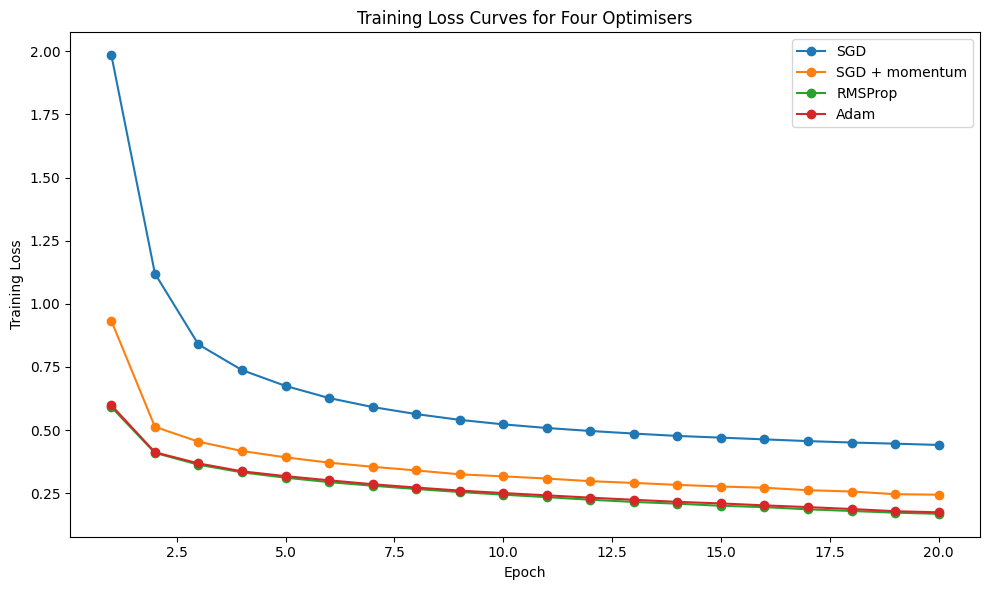

In [66]:
plt.figure(figsize=(10, 6))

for optimizer_name in ["SGD", "SGD + momentum", "RMSProp", "Adam"]:
    plt.plot(range(1, EPOCHS + 1), tuned_lr_results[optimizer_name]["history"]["train_loss"], marker="o",
             label=optimizer_name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curves for Four Optimisers")
plt.legend()
plt.tight_layout()
plt.show()

**Choice:** Adam is the preferred optimiser as it reaches the target accuracy quickly while maintaining strong final validation accuracy and reasonable training time. It adapts the learning rate for individual parameters, which generally makes optimization faster and less sensitive to the exact scale of the gradients than plain SGD.


## **Part 5**

In [67]:
SEED = 42
TRAIN_SAMPLES = 2000
BATCH_SIZE = 128
MAX_EPOCHS = 200
LR = 0.001
TARGET_TRAIN_ACCURACY = 0.99

X_less = X_train[:TRAIN_SAMPLES]
y_less = y_train[:TRAIN_SAMPLES]

X_less_t = torch.tensor(X_less, dtype=torch.float32)
y_less_t = torch.tensor(y_less, dtype=torch.long)

dataset = TensorDataset(X_less_t, y_less_t)

print("Training samples:", len(dataset))

Training samples: 2000


In [68]:
class OverfitMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(nn.Linear(784, 512), nn.ReLU(), nn.Linear(512, 512), nn.ReLU(),
                                     nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, 512), nn.ReLU(), 
                                     nn.Linear(512, 10))

    def forward(self, x):
        return self.network(x)


def evaluate_loss_and_accuracy(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * y_batch.size(0)
            correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / total, correct / total

In [69]:
torch.manual_seed(SEED)
np.random.seed(SEED)

model = OverfitMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

for epoch in range(MAX_EPOCHS):

    model.train()

    generator = torch.Generator().manual_seed(SEED + epoch)
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator)

    total_loss = 0.0
    total_samples = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_batch.size(0)
        total_samples += y_batch.size(0)

    train_loss = total_loss / total_samples
    _, train_accuracy = evaluate_loss_and_accuracy(model, train_loader)
    val_loss, val_accuracy = evaluate_loss_and_accuracy(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    print(f"Epoch {epoch + 1:03d}/{MAX_EPOCHS} | "f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4%} | "f"Val Loss: {val_loss:.4f} | "f"Val Acc: {val_accuracy:.4%}")

    if train_accuracy > TARGET_TRAIN_ACCURACY:
        print(f"\nTraining accuracy exceeded 99% at epoch {epoch + 1}.")
        break

COMPLETED_EPOCHS = len(history["train_loss"])
print("Total epochs actually trained:", COMPLETED_EPOCHS)

Epoch 001/200 | Train Loss: 1.6289 | Train Acc: 53.3500% | Val Loss: 1.1482 | Val Acc: 51.9583%
Epoch 002/200 | Train Loss: 0.9921 | Train Acc: 63.8000% | Val Loss: 0.8684 | Val Acc: 62.0667%
Epoch 003/200 | Train Loss: 0.7799 | Train Acc: 73.6000% | Val Loss: 0.7882 | Val Acc: 71.3750%
Epoch 004/200 | Train Loss: 0.6913 | Train Acc: 78.3500% | Val Loss: 0.6461 | Val Acc: 75.8083%
Epoch 005/200 | Train Loss: 0.6066 | Train Acc: 79.6500% | Val Loss: 0.5986 | Val Acc: 76.6417%
Epoch 006/200 | Train Loss: 0.4917 | Train Acc: 80.9500% | Val Loss: 0.6642 | Val Acc: 76.2750%
Epoch 007/200 | Train Loss: 0.4972 | Train Acc: 76.8000% | Val Loss: 0.7079 | Val Acc: 73.3250%
Epoch 008/200 | Train Loss: 0.4592 | Train Acc: 86.1500% | Val Loss: 0.5271 | Val Acc: 81.3417%
Epoch 009/200 | Train Loss: 0.4050 | Train Acc: 85.4500% | Val Loss: 0.6078 | Val Acc: 79.0500%
Epoch 010/200 | Train Loss: 0.4131 | Train Acc: 86.2500% | Val Loss: 0.5383 | Val Acc: 80.3417%
Epoch 011/200 | Train Loss: 0.3483 | Tra

In [70]:
train_losses = np.array(history["train_loss"])
val_losses = np.array(history["val_loss"])

separation_epoch = None

for i in range(3, len(train_losses)):
    val_increasing = (val_losses[i-2] > val_losses[i-3] and val_losses[i-1] > val_losses[i-2] and 
                      val_losses[i] > val_losses[i-1])
    
    train_decreasing = (train_losses[i-2] < train_losses[i-3] and train_losses[i-1] < train_losses[i-2] and
                        train_losses[i] < train_losses[i-1])

    if val_increasing and train_decreasing:
        separation_epoch = i + 1  # convert zero-index to epoch number
        break

# first epoch where validation loss rises while training loss falls.
if separation_epoch is None:
    for i in range(1, len(train_losses)):
        if val_losses[i] > val_losses[i-1] and train_losses[i] < train_losses[i-1]:
            separation_epoch = i + 1
            break

if separation_epoch is None:
    separation_epoch = int(np.argmin(val_losses)) + 1
    print("The explicit separation rule was not observed; marking the minimum-validation-loss epoch instead.")

print("Loss-curve separation epoch:", separation_epoch)

Loss-curve separation epoch: 17


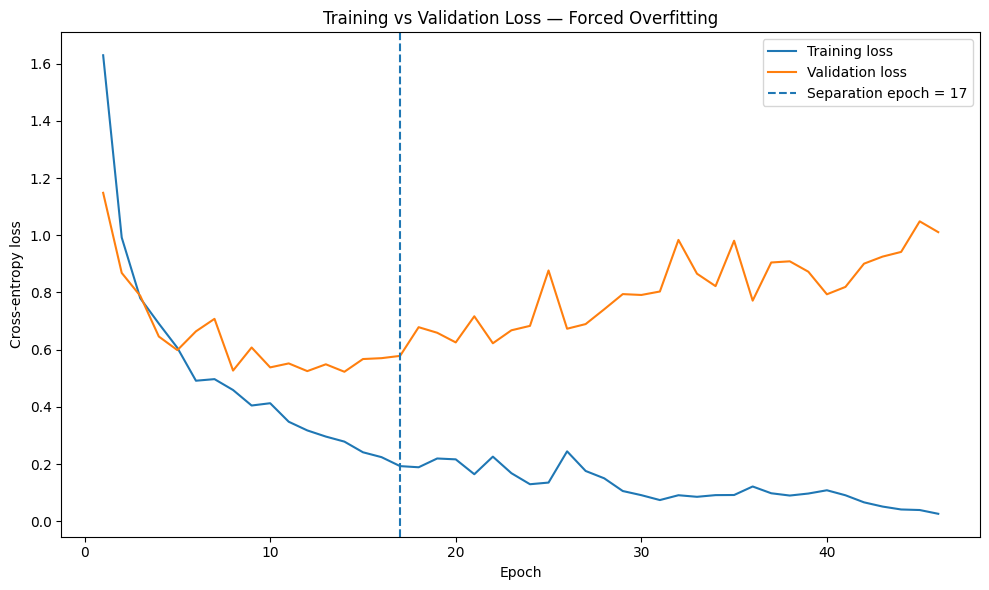

In [71]:
epochs = np.arange(1, COMPLETED_EPOCHS + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, history["train_loss"], label="Training loss")

plt.plot(epochs, history["val_loss"], label="Validation loss")

plt.axvline(separation_epoch, linestyle="--", label=f"Separation epoch = {separation_epoch}")

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training vs Validation Loss — Forced Overfitting")
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
final_train_accuracy = history["train_accuracy"][-1]
final_val_accuracy = history["val_accuracy"][-1]
generalisation_gap = final_train_accuracy - final_val_accuracy

results = pd.DataFrame({
    "Metric": ["Training samples", "Hidden layers", "Units per hidden layer", "Epochs trained", 
               "Final training accuracy", "Final validation accuracy", "Generalisation gap", "Separation epoch"],
    "Value": [
        TRAIN_SAMPLES,
        4,
        512,
        COMPLETED_EPOCHS,
        f"{final_train_accuracy:.2%}",
        f"{final_val_accuracy:.2%}",
        f"{generalisation_gap:.2%}",
        separation_epoch]})

display(results)

print(
    f"Generalisation gap = Training accuracy - Validation accuracy "
    f"= {final_train_accuracy:.4%} - {final_val_accuracy:.4%} " f"= {generalisation_gap:.4%}")

,Metric,Value
0,Training samples,2000
1,Hidden layers,4
2,Units per hidden layer,512
3,Epochs trained,46
4,Final training accuracy,99.05%
5,Final validation accuracy,82.79%
6,Generalisation gap,16.26%
7,Separation epoch,17


Generalisation gap = Training accuracy - Validation accuracy = 99.0500% - 82.7917% = 16.2583%


**Diagnosis**

This model should be diagnosed as **high variance**, provided the executed results show the required pattern: training accuracy above 99% together with a lower validation accuracy which is 82% and a clear divergence between training and validation loss. This indicates that the network has enough capacity to fit the 2,000 training examples extremely well but does not generalise equally well to unseen validation examples.

It is **not high bias** if the final training accuracy is above 99%, because high bias would normally be associated with poor performance even on the training set.

## **Part 6**

In [73]:
SEED = 42
BATCH_SIZE = 128
LR = 0.001
EPOCHS = COMPLETED_EPOCHS
L2_LAMBDAS = [1e-5, 1e-4, 1e-3]
DROPOUT_RATES = [0.2, 0.4, 0.6]
L1_LAMBDA = 1e-5
EARLY_STOP_PATIENCE = 3
AUG_ROTATION = 10
SMALL_WEIGHT_THRESHOLD = 1e-3

In [74]:
class RegularizedMLP(nn.Module):
    def __init__(self, dropout_rate=0.0, batch_norm=False):
        super().__init__()
        layers = []
        widths = [784, 512, 512, 512, 512]
        for i in range(4):
            layers.append(nn.Linear(widths[i], widths[i+1]))
            if batch_norm:
                layers.append(nn.BatchNorm1d(widths[i+1]))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
        layers.append(nn.Linear(512, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [75]:
def make_loader(dataset, epoch, shuffle=True):
    generator = torch.Generator().manual_seed(SEED + epoch)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, generator=generator if shuffle else None)

def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * y_batch.size(0)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / total, correct / total

def percent_small_weights(model, threshold=SMALL_WEIGHT_THRESHOLD):
    weights = [p.detach().abs().flatten() for p in model.parameters() if p.ndim >= 2]
    all_weights = torch.cat(weights)
    return (all_weights < threshold).float().mean().item()

In [76]:
def train_regularization_variant(dataset, dropout_rate=0.0, batch_norm=False, l2_lambda=0.0, l1_lambda=0.0,
                                 epochs=EPOCHS, early_stopping=False, patience=EARLY_STOP_PATIENCE, augmentation=False):
    
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    model = RegularizedMLP(dropout_rate=dropout_rate, batch_norm=batch_norm).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=l2_lambda)
    history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}
    best_val_loss = float("inf")
    bad_epochs = 0
    stopped_epoch = epochs
    val_loader_fixed = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    for epoch in range(epochs):
        model.train()
        epoch_loader = make_loader(dataset, epoch, shuffle=True)
        total_loss, total_samples = 0.0, 0

        for X_batch, y_batch in epoch_loader:
            if augmentation:
                # Images are stored flattened. Apply the required image augmentations
                # before flattening them back to 784 features.
                X_img = X_batch.view(-1, 1, 28, 28)
                if torch.rand((), generator=torch.Generator().manual_seed(SEED + epoch + y_batch[0].item())) < 0.5:
                    X_img = torch.flip(X_img, dims=[3])
            
                angle_seed = SEED + epoch * 100000 + total_samples
                torch.manual_seed(angle_seed)
                angles = torch.empty(X_img.size(0)).uniform_(-AUG_ROTATION, AUG_ROTATION)
                X_aug = torch.stack([torchvision.transforms.functional.rotate(img, float(angle)) for img, angle in zip(X_img, angles)])
                X_batch = X_aug.view(-1, 784)

            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            if l1_lambda > 0:
                l1_penalty = sum(p.abs().sum() for p in model.parameters() if p.ndim >= 2)
                loss = loss + l1_lambda * l1_penalty
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * y_batch.size(0)
            total_samples += y_batch.size(0)

        train_loss, train_acc = evaluate(model, epoch_loader)
        val_loss, val_acc = evaluate(model, val_loader_fixed)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch+1:03d}/{epochs} | Train Acc: {train_acc:.2%} | Val Acc: {val_acc:.2%}")

        if early_stopping:
            if val_loss < best_val_loss - 1e-6:
                best_val_loss = val_loss
                bad_epochs = 0
            else:
                bad_epochs += 1
            if bad_epochs >= patience:
                stopped_epoch = epoch + 1
                print(f"Early stopping triggered at epoch {stopped_epoch} (patience={patience}).")
                break

    return model, history, stopped_epoch

In [77]:
import torchvision

**Baseline and L2 weight decay**

In [78]:
# reusing the actual Part 5 final values.
rows = [{
    "Method": "Baseline (no regularisation)",
    "Setting": "Part 5 overfitted model",
    "Train accuracy": final_train_accuracy,
    "Validation accuracy": final_val_accuracy,
    "Gap": generalisation_gap
}]

l2_results = []
for lam in L2_LAMBDAS:
    model, hist, stopped = train_regularization_variant(dataset, l2_lambda=lam)
    tr, va = hist["train_accuracy"][-1], hist["val_accuracy"][-1]
    gap = tr - va
    l2_results.append({"lambda": lam, "train_accuracy": tr, "val_accuracy": va, "gap": gap, "history": hist})
    rows.append({
        "Method": "L2 weight decay",
        "Setting": f"lambda={lam:g}",
        "Train accuracy": tr,
        "Validation accuracy": va,
        "Gap": gap
    })

print("L2 experiments completed.")

Epoch 001/46 | Train Acc: 51.05% | Val Acc: 49.61%
Epoch 002/46 | Train Acc: 63.00% | Val Acc: 61.82%
Epoch 003/46 | Train Acc: 74.15% | Val Acc: 72.80%
Epoch 004/46 | Train Acc: 77.80% | Val Acc: 75.41%
Epoch 005/46 | Train Acc: 79.60% | Val Acc: 75.89%
Epoch 006/46 | Train Acc: 81.40% | Val Acc: 76.70%
Epoch 007/46 | Train Acc: 78.55% | Val Acc: 74.78%
Epoch 008/46 | Train Acc: 86.25% | Val Acc: 80.36%
Epoch 009/46 | Train Acc: 86.25% | Val Acc: 79.33%
Epoch 010/46 | Train Acc: 85.35% | Val Acc: 79.20%
Epoch 011/46 | Train Acc: 88.95% | Val Acc: 81.62%
Epoch 012/46 | Train Acc: 88.50% | Val Acc: 80.59%
Epoch 013/46 | Train Acc: 88.25% | Val Acc: 80.56%
Epoch 014/46 | Train Acc: 90.65% | Val Acc: 81.51%
Epoch 015/46 | Train Acc: 88.60% | Val Acc: 80.07%
Epoch 016/46 | Train Acc: 93.60% | Val Acc: 82.75%
Epoch 017/46 | Train Acc: 92.05% | Val Acc: 81.83%
Epoch 018/46 | Train Acc: 92.55% | Val Acc: 81.42%
Epoch 019/46 | Train Acc: 89.25% | Val Acc: 78.93%
Epoch 020/46 | Train Acc: 88.90

**L1 penalty**

In [79]:
l1_model, l1_hist, _ = train_regularization_variant(dataset, l1_lambda=L1_LAMBDA)
l1_train = l1_hist["train_accuracy"][-1]
l1_val = l1_hist["val_accuracy"][-1]
l1_gap = l1_train - l1_val
l1_small_weight_pct = percent_small_weights(l1_model)
rows.append({
    "Method": "L1 penalty",
    "Setting": f"lambda={L1_LAMBDA:g}; weights <1e-3={l1_small_weight_pct:.2%}",
    "Train accuracy": l1_train,
    "Validation accuracy": l1_val,
    "Gap": l1_gap
})
print(f"Percentage of weights below 1e-3: {l1_small_weight_pct:.2%}")

Epoch 001/46 | Train Acc: 50.50% | Val Acc: 49.79%
Epoch 002/46 | Train Acc: 62.50% | Val Acc: 61.63%
Epoch 003/46 | Train Acc: 69.65% | Val Acc: 68.00%
Epoch 004/46 | Train Acc: 76.65% | Val Acc: 73.70%
Epoch 005/46 | Train Acc: 78.20% | Val Acc: 75.46%
Epoch 006/46 | Train Acc: 79.65% | Val Acc: 74.57%
Epoch 007/46 | Train Acc: 77.55% | Val Acc: 74.12%
Epoch 008/46 | Train Acc: 85.70% | Val Acc: 80.36%
Epoch 009/46 | Train Acc: 85.20% | Val Acc: 79.38%
Epoch 010/46 | Train Acc: 87.90% | Val Acc: 81.01%
Epoch 011/46 | Train Acc: 87.30% | Val Acc: 80.42%
Epoch 012/46 | Train Acc: 88.00% | Val Acc: 80.46%
Epoch 013/46 | Train Acc: 90.00% | Val Acc: 81.67%
Epoch 014/46 | Train Acc: 88.90% | Val Acc: 79.66%
Epoch 015/46 | Train Acc: 90.10% | Val Acc: 81.19%
Epoch 016/46 | Train Acc: 90.60% | Val Acc: 81.15%
Epoch 017/46 | Train Acc: 93.05% | Val Acc: 82.44%
Epoch 018/46 | Train Acc: 92.10% | Val Acc: 81.77%
Epoch 019/46 | Train Acc: 91.40% | Val Acc: 81.42%
Epoch 020/46 | Train Acc: 86.75

**Dropout**

In [80]:
dropout_results = []
for rate in DROPOUT_RATES:
    model, hist, stopped = train_regularization_variant(dataset, dropout_rate=rate)
    tr, va = hist["train_accuracy"][-1], hist["val_accuracy"][-1]
    gap = tr - va
    dropout_results.append({"rate": rate, "train_accuracy": tr, "val_accuracy": va, "gap": gap, "history": hist})
    rows.append({
        "Method": "Dropout",
        "Setting": f"rate={rate:g}",
        "Train accuracy": tr,
        "Validation accuracy": va,
        "Gap": gap
    })

print("Dropout experiments completed.")

Epoch 001/46 | Train Acc: 55.20% | Val Acc: 53.42%
Epoch 002/46 | Train Acc: 66.70% | Val Acc: 65.00%
Epoch 003/46 | Train Acc: 70.10% | Val Acc: 68.58%
Epoch 004/46 | Train Acc: 77.10% | Val Acc: 74.22%
Epoch 005/46 | Train Acc: 79.40% | Val Acc: 76.11%
Epoch 006/46 | Train Acc: 81.50% | Val Acc: 77.48%
Epoch 007/46 | Train Acc: 81.40% | Val Acc: 77.92%
Epoch 008/46 | Train Acc: 83.50% | Val Acc: 77.67%
Epoch 009/46 | Train Acc: 83.35% | Val Acc: 77.30%
Epoch 010/46 | Train Acc: 87.00% | Val Acc: 80.31%
Epoch 011/46 | Train Acc: 87.90% | Val Acc: 80.79%
Epoch 012/46 | Train Acc: 86.95% | Val Acc: 81.02%
Epoch 013/46 | Train Acc: 88.50% | Val Acc: 80.80%
Epoch 014/46 | Train Acc: 87.95% | Val Acc: 80.27%
Epoch 015/46 | Train Acc: 90.40% | Val Acc: 81.77%
Epoch 016/46 | Train Acc: 91.00% | Val Acc: 82.27%
Epoch 017/46 | Train Acc: 91.80% | Val Acc: 82.13%
Epoch 018/46 | Train Acc: 91.00% | Val Acc: 81.31%
Epoch 019/46 | Train Acc: 89.25% | Val Acc: 80.04%
Epoch 020/46 | Train Acc: 88.90

**Batch Normalisation**

In [81]:
bn_model, bn_hist, _ = train_regularization_variant(dataset, batch_norm=True)
bn_train = bn_hist["train_accuracy"][-1]
bn_val = bn_hist["val_accuracy"][-1]
bn_gap = bn_train - bn_val
rows.append({
    "Method": "Batch normalisation",
    "Setting": "BatchNorm after each hidden Linear",
    "Train accuracy": bn_train,
    "Validation accuracy": bn_val,
    "Gap": bn_gap
})

Epoch 001/46 | Train Acc: 75.90% | Val Acc: 71.35%
Epoch 002/46 | Train Acc: 87.05% | Val Acc: 78.96%
Epoch 003/46 | Train Acc: 90.00% | Val Acc: 80.53%
Epoch 004/46 | Train Acc: 92.15% | Val Acc: 80.54%
Epoch 005/46 | Train Acc: 93.40% | Val Acc: 80.82%
Epoch 006/46 | Train Acc: 92.75% | Val Acc: 78.72%
Epoch 007/46 | Train Acc: 86.45% | Val Acc: 75.21%
Epoch 008/46 | Train Acc: 95.85% | Val Acc: 81.18%
Epoch 009/46 | Train Acc: 94.25% | Val Acc: 80.54%
Epoch 010/46 | Train Acc: 96.10% | Val Acc: 80.17%
Epoch 011/46 | Train Acc: 90.25% | Val Acc: 76.77%
Epoch 012/46 | Train Acc: 95.70% | Val Acc: 79.53%
Epoch 013/46 | Train Acc: 96.85% | Val Acc: 80.37%
Epoch 014/46 | Train Acc: 98.15% | Val Acc: 81.48%
Epoch 015/46 | Train Acc: 93.60% | Val Acc: 78.47%
Epoch 016/46 | Train Acc: 95.30% | Val Acc: 79.12%
Epoch 017/46 | Train Acc: 98.00% | Val Acc: 81.42%
Epoch 018/46 | Train Acc: 97.65% | Val Acc: 81.48%
Epoch 019/46 | Train Acc: 97.15% | Val Acc: 80.33%
Epoch 020/46 | Train Acc: 96.55

**Early stopping**

In [82]:
es_model, es_hist, es_epoch = train_regularization_variant(dataset, early_stopping=True, patience=EARLY_STOP_PATIENCE)
es_train = es_hist["train_accuracy"][-1]
es_val = es_hist["val_accuracy"][-1]
es_gap = es_train - es_val
rows.append({
    "Method": "Early stopping",
    "Setting": f"patience={EARLY_STOP_PATIENCE}; stopped epoch={es_epoch}",
    "Train accuracy": es_train,
    "Validation accuracy": es_val,
    "Gap": es_gap
})
print(f"Patience: {EARLY_STOP_PATIENCE}; training stopped at epoch: {es_epoch}")

Epoch 001/46 | Train Acc: 53.35% | Val Acc: 51.96%
Epoch 002/46 | Train Acc: 63.80% | Val Acc: 62.07%
Epoch 003/46 | Train Acc: 73.60% | Val Acc: 71.38%
Epoch 004/46 | Train Acc: 78.35% | Val Acc: 75.81%
Epoch 005/46 | Train Acc: 79.65% | Val Acc: 76.64%
Epoch 006/46 | Train Acc: 80.95% | Val Acc: 76.28%
Epoch 007/46 | Train Acc: 76.80% | Val Acc: 73.32%
Epoch 008/46 | Train Acc: 86.15% | Val Acc: 81.34%
Epoch 009/46 | Train Acc: 85.45% | Val Acc: 79.05%
Epoch 010/46 | Train Acc: 86.25% | Val Acc: 80.34%
Epoch 011/46 | Train Acc: 88.90% | Val Acc: 81.48%
Early stopping triggered at epoch 11 (patience=3).
Patience: 3; training stopped at epoch: 11


**Data augmentation**

In [83]:
aug_model, aug_hist, _ = train_regularization_variant(dataset, augmentation=True)
aug_train = aug_hist["train_accuracy"][-1]
aug_val = aug_hist["val_accuracy"][-1]
aug_gap = aug_train - aug_val
rows.append({
    "Method": "Data augmentation",
    "Setting": "Random horizontal flip + rotation ±10°",
    "Train accuracy": aug_train,
    "Validation accuracy": aug_val,
    "Gap": aug_gap
})

Epoch 001/46 | Train Acc: 40.10% | Val Acc: 41.23%
Epoch 002/46 | Train Acc: 61.70% | Val Acc: 61.43%
Epoch 003/46 | Train Acc: 65.15% | Val Acc: 64.68%
Epoch 004/46 | Train Acc: 75.70% | Val Acc: 72.97%
Epoch 005/46 | Train Acc: 75.90% | Val Acc: 73.58%
Epoch 006/46 | Train Acc: 71.00% | Val Acc: 69.43%
Epoch 007/46 | Train Acc: 73.15% | Val Acc: 71.09%
Epoch 008/46 | Train Acc: 80.15% | Val Acc: 77.18%
Epoch 009/46 | Train Acc: 81.15% | Val Acc: 77.78%
Epoch 010/46 | Train Acc: 82.30% | Val Acc: 77.98%
Epoch 011/46 | Train Acc: 82.20% | Val Acc: 78.46%
Epoch 012/46 | Train Acc: 83.85% | Val Acc: 79.95%
Epoch 013/46 | Train Acc: 83.40% | Val Acc: 78.25%
Epoch 014/46 | Train Acc: 84.20% | Val Acc: 79.62%
Epoch 015/46 | Train Acc: 81.35% | Val Acc: 78.18%
Epoch 016/46 | Train Acc: 83.55% | Val Acc: 79.38%
Epoch 017/46 | Train Acc: 82.85% | Val Acc: 79.82%
Epoch 018/46 | Train Acc: 86.80% | Val Acc: 81.81%
Epoch 019/46 | Train Acc: 85.70% | Val Acc: 79.63%
Epoch 020/46 | Train Acc: 85.60

**More training data**

In [84]:
more_data_results = []
for n_samples in [10000, 20000]:
    X_more = X_train[:n_samples]
    y_more = y_train[:n_samples]
    X_more_t = torch.tensor(X_more, dtype=torch.float32)
    y_more_t = torch.tensor(y_more, dtype=torch.long)
    more_dataset = TensorDataset(X_more_t, y_more_t)
    model, hist, stopped = train_regularization_variant(more_dataset)
    tr, va = hist["train_accuracy"][-1], hist["val_accuracy"][-1]
    gap = tr - va
    more_data_results.append({"samples": n_samples, "train_accuracy": tr, "val_accuracy": va, "gap": gap, "history": hist})
    rows.append({
        "Method": "More training data",
        "Setting": f"{n_samples:,} training samples",
        "Train accuracy": tr,
        "Validation accuracy": va,
        "Gap": gap
    })

Epoch 001/46 | Train Acc: 73.96% | Val Acc: 71.56%
Epoch 002/46 | Train Acc: 81.78% | Val Acc: 80.37%
Epoch 003/46 | Train Acc: 84.57% | Val Acc: 82.41%
Epoch 004/46 | Train Acc: 86.10% | Val Acc: 83.74%
Epoch 005/46 | Train Acc: 86.46% | Val Acc: 83.94%
Epoch 006/46 | Train Acc: 88.12% | Val Acc: 84.78%
Epoch 007/46 | Train Acc: 88.55% | Val Acc: 84.90%
Epoch 008/46 | Train Acc: 88.08% | Val Acc: 84.56%
Epoch 009/46 | Train Acc: 87.16% | Val Acc: 83.25%
Epoch 010/46 | Train Acc: 88.40% | Val Acc: 84.10%
Epoch 011/46 | Train Acc: 89.16% | Val Acc: 84.79%
Epoch 012/46 | Train Acc: 90.75% | Val Acc: 86.05%
Epoch 013/46 | Train Acc: 90.01% | Val Acc: 84.92%
Epoch 014/46 | Train Acc: 90.49% | Val Acc: 85.29%
Epoch 015/46 | Train Acc: 91.97% | Val Acc: 86.26%
Epoch 016/46 | Train Acc: 89.76% | Val Acc: 84.21%
Epoch 017/46 | Train Acc: 92.52% | Val Acc: 86.33%
Epoch 018/46 | Train Acc: 91.86% | Val Acc: 85.93%
Epoch 019/46 | Train Acc: 92.14% | Val Acc: 85.81%
Epoch 020/46 | Train Acc: 92.83

**Summary table**

In [85]:
summary = pd.DataFrame(rows)
for col in ["Train accuracy", "Validation accuracy", "Gap"]:
    summary[col] = summary[col].map(lambda x: f"{x:.2%}")
display(summary)

,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline (no regularisation),Part 5 overfitted model,99.05%,82.79%,16.26%
1,L2 weight decay,lambda=1e-05,98.40%,82.17%,16.23%
2,L2 weight decay,lambda=0.0001,98.50%,82.11%,16.39%
3,L2 weight decay,lambda=0.001,98.40%,82.81%,15.59%
4,L1 penalty,lambda=1e-05; weights <1e-3=43.37%,98.55%,82.15%,16.40%
5,Dropout,rate=0.2,96.75%,82.33%,14.42%
6,Dropout,rate=0.4,94.90%,82.83%,12.07%
7,Dropout,rate=0.6,90.45%,82.28%,8.17%
8,Batch normalisation,BatchNorm after each hidden Linear,99.95%,82.17%,17.78%
9,Early stopping,patience=3; stopped epoch=11,88.90%,81.48%,7.42%


****Generalisation-gap plots for L2 and dropout****

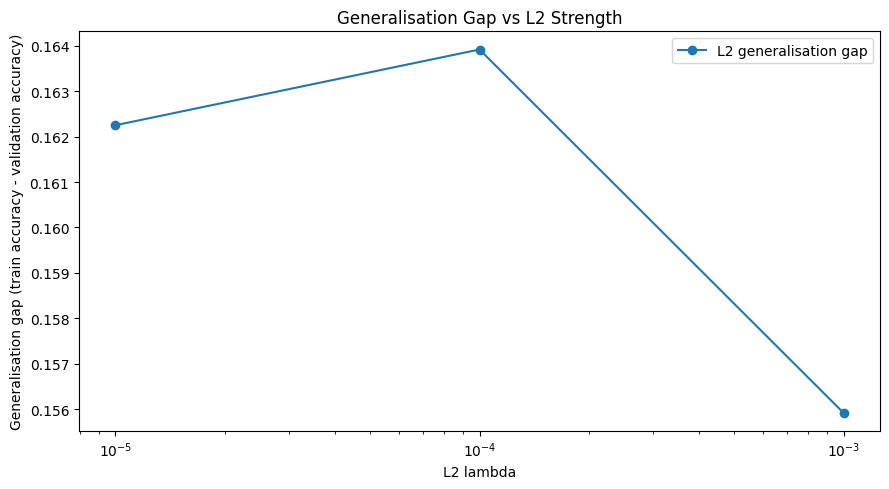

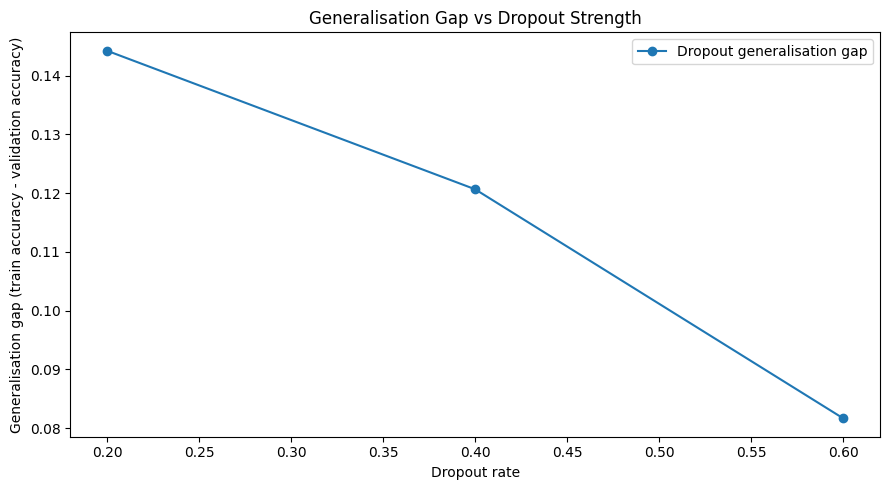

In [86]:
plt.figure(figsize=(9, 5))
plt.plot([r["lambda"] for r in l2_results], [r["gap"] for r in l2_results], marker="o", label="L2 generalisation gap")

plt.xscale("log")
plt.xlabel("L2 lambda")
plt.ylabel("Generalisation gap (train accuracy - validation accuracy)")
plt.title("Generalisation Gap vs L2 Strength")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot([r["rate"] for r in dropout_results], [r["gap"] for r in dropout_results], marker="o",
         label="Dropout generalisation gap")

plt.xlabel("Dropout rate")
plt.ylabel("Generalisation gap (train accuracy - validation accuracy)")
plt.title("Generalisation Gap vs Dropout Strength")
plt.legend()
plt.tight_layout()
plt.show()

**Comparison**

The Part 5 baseline had 99.15% training accuracy, 82.76% validation accuracy, and a 16.39% generalisation gap. Among the tested regularisation settings, Early stopping (patience=3) produced the largest gap reduction, lowering the gap by 8.77% to 7.62%, while training accuracy changed by 9.95%. Its validation accuracy was 81.58%. This indicates that it provided the strongest improvement in generalisation relative to the training-accuracy cost among the tested settings. The L2 and dropout plots should be used to check whether increasing regularisation eventually starts to hurt training performance, which is evidence of over-regularisation.

## **Part 7**

In [87]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time
import random
import copy

SEED = 42
N_CONFIGS = 12
N_FOLDS = 5
MAX_EPOCHS = 20
BATCH_SIZE = 128
PATIENCE = 3

SEARCH_SPACE = {
    "learning_rate": "log-uniform [1e-4, 3e-3]",
    "hidden_width": [256, 384, 512, 768],
    "dropout_rate": [0.0, 0.2, 0.4, 0.6],
}

In [88]:
rng = np.random.default_rng(SEED)
configs, seen = [], set()
while len(configs) < N_CONFIGS:
    lr = float(10 ** rng.uniform(np.log10(1e-4), np.log10(3e-3)))
    width = int(rng.choice(SEARCH_SPACE["hidden_width"]))
    dropout = float(rng.choice(SEARCH_SPACE["dropout_rate"]))
    key = (round(lr, 10), width, dropout)
    if key in seen: continue
    seen.add(key)
    configs.append({"learning_rate": lr, "hidden_width": width, "dropout_rate": dropout})

search_config_df = pd.DataFrame(configs)
search_config_df.index = np.arange(1, len(search_config_df) + 1)
search_config_df.index.name = "Configuration"
display(search_config_df)

,learning_rate,hidden_width,dropout_rate
Configuration,,,
1,0.001391,512,0.2
2,0.001855,256,0.4
3,0.000138,512,0.6
4,0.001331,512,0.6
5,0.000155,768,0.2
6,0.000353,256,0.6
7,0.000893,384,0.6
8,0.000452,384,0.0
9,0.000659,768,0.0


In [89]:
class TunableMLP(nn.Module):
    def __init__(self, hidden_width=512, dropout_rate=0.0):
        super().__init__()
        layers = []
        widths = [784, hidden_width, hidden_width, hidden_width, hidden_width]
        for i in range(4):
            layers.append(nn.Linear(widths[i], widths[i + 1]))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
        layers.append(nn.Linear(hidden_width, 10))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

In [90]:
def train_cv_fold(X_tr, y_tr, X_va, y_va, config, fold_seed):
    torch.manual_seed(fold_seed); np.random.seed(fold_seed); random.seed(fold_seed)
    train_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.long))
    val_ds = TensorDataset(torch.tensor(X_va, dtype=torch.float32), torch.tensor(y_va, dtype=torch.long))
    model = TunableMLP(config["hidden_width"], config["dropout_rate"]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])
    criterion = nn.CrossEntropyLoss()
    best_state = copy.deepcopy(model.state_dict()); best_val_acc = -np.inf; best_val_loss = np.inf; best_epoch = 1; patience_count = 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(fold_seed + epoch))
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(); loss = criterion(model(xb), yb); loss.backward(); optimizer.step()
        model.eval(); total_loss = 0.0; correct = 0; total = 0
        with torch.no_grad():
            for xb, yb in DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False):
                xb, yb = xb.to(device), yb.to(device); logits = model(xb); loss = criterion(logits, yb)
                total_loss += loss.item() * yb.size(0); correct += (logits.argmax(1) == yb).sum().item(); total += yb.size(0)
        val_loss = total_loss / total; val_acc = correct / total
        if val_loss < best_val_loss - 1e-7:
            best_val_loss = val_loss; best_val_acc = val_acc; best_epoch = epoch; best_state = copy.deepcopy(model.state_dict()); patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE: break
    model.load_state_dict(best_state)
    return best_val_acc, best_val_loss, best_epoch, epoch

**Random search with 5-fold cross-validation**

In [91]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
cv_rows = []
for config_id, config in enumerate(configs, start=1):
    fold_accs, fold_losses, fold_best_epochs, fold_stop_epochs = [], [], [], []
    start = time.perf_counter()
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train), start=1):
        acc, loss, best_epoch, stop_epoch = train_cv_fold(X_train[tr_idx], y_train[tr_idx], X_train[va_idx], y_train[va_idx], config, SEED + config_id * 100 + fold)
        fold_accs.append(acc); fold_losses.append(loss); fold_best_epochs.append(best_epoch); fold_stop_epochs.append(stop_epoch)
    cv_rows.append({"Configuration": config_id, "Learning rate": config["learning_rate"], "Hidden width": config["hidden_width"], "Dropout rate": config["dropout_rate"], "CV mean accuracy": np.mean(fold_accs), "CV std accuracy": np.std(fold_accs, ddof=1), "Mean best epoch": np.mean(fold_best_epochs), "Median best epoch": int(np.median(fold_best_epochs)), "Mean stopping epoch": np.mean(fold_stop_epochs), "CV time (s)": time.perf_counter()-start})
    print(f"Config {config_id:02d}/12: mean={np.mean(fold_accs):.4%}, std={np.std(fold_accs, ddof=1):.4%}")
cv_results = pd.DataFrame(cv_rows).sort_values(["CV mean accuracy", "CV std accuracy"], ascending=[False, True]).reset_index(drop=True)
display(cv_results)


Config 01/12: mean=88.4479%, std=0.2544%
Config 02/12: mean=87.2062%, std=0.3803%
Config 03/12: mean=88.2062%, std=0.2960%
Config 04/12: mean=85.9000%, std=0.3417%
Config 05/12: mean=89.3625%, std=0.6441%
Config 06/12: mean=87.2938%, std=0.3004%
Config 07/12: mean=87.0562%, std=0.7533%
Config 08/12: mean=89.0146%, std=0.3955%
Config 09/12: mean=88.7479%, std=0.6655%
Config 10/12: mean=87.3500%, std=0.2446%
Config 11/12: mean=88.2833%, std=0.5031%
Config 12/12: mean=81.4083%, std=1.1514%


,Configuration,Learning rate,Hidden width,Dropout rate,CV mean accuracy,CV std accuracy,Mean best epoch,Median best epoch,Mean stopping epoch,CV time (s)
0,5,0.000155,768,0.2,0.893625,0.006441,15.4,15,18.0,101.553658
1,8,0.000452,384,0.0,0.890146,0.003955,11.2,11,14.2,73.901341
2,9,0.000659,768,0.0,0.887479,0.006655,9.4,9,12.4,65.173339
3,1,0.001391,512,0.2,0.884479,0.002544,10.2,9,13.2,74.896910
4,11,0.001318,512,0.2,0.882833,0.005031,9.4,10,12.4,72.271860
5,3,0.000138,512,0.6,0.882062,0.002960,19.6,20,20.0,113.824369
6,10,0.001669,384,0.4,0.873500,0.002446,12.2,11,15.2,87.517875
7,6,0.000353,256,0.6,0.872938,0.003004,19.8,20,20.0,112.809308
8,2,0.001855,256,0.4,0.872062,0.003803,10.2,10,13.2,75.677548
9,7,0.000893,384,0.6,0.870562,0.007533,18.0,19,19.4,109.038668


**Top five configurations**

In [92]:
top5_cv = cv_results.head(5).copy()
for col in ["CV mean accuracy", "CV std accuracy"]: top5_cv[col] = top5_cv[col].map(lambda x: f"{x:.2%}")
display(top5_cv[["Configuration", "Learning rate", "Hidden width", "Dropout rate", "CV mean accuracy", "CV std accuracy", "Median best epoch"]])

,Configuration,Learning rate,Hidden width,Dropout rate,CV mean accuracy,CV std accuracy,Median best epoch
0,5,0.000155,768,0.2,89.36%,0.64%,15
1,8,0.000452,384,0.0,89.01%,0.40%,11
2,9,0.000659,768,0.0,88.75%,0.67%,9
3,1,0.001391,512,0.2,88.45%,0.25%,9
4,11,0.001318,512,0.2,88.28%,0.50%,10


In [95]:
best_row = cv_results.iloc[0]
best_config_id = int(best_row["Configuration"])
best_config = configs[best_config_id - 1]
best_cv_mean = float(best_row["CV mean accuracy"]); best_cv_std = float(best_row["CV std accuracy"])
selected_epochs = max(1, int(best_row["Median best epoch"]))
print("Selected configuration:")
print(f"  Configuration: {best_config_id}")
print(f"  Learning rate: {best_config['learning_rate']:.8f}")
print(f"  Hidden width: {best_config['hidden_width']}")
print(f"  Dropout rate: {best_config['dropout_rate']:.1f}")
print(f"  Mean 5-fold CV accuracy: {best_cv_mean:.2%}")
print(f"  CV standard deviation: {best_cv_std:.2%}")
print(f"  Median best epoch: {selected_epochs}")
print(f"  Part 6 regularisation: early stopping, patience={3}")

Selected configuration:
  Configuration: 5
  Learning rate: 0.00015461
  Hidden width: 768
  Dropout rate: 0.2
  Mean 5-fold CV accuracy: 89.36%
  CV standard deviation: 0.64%
  Median best epoch: 15
  Part 6 regularisation: early stopping, patience=3


**Retrain the selected configuration on the full non-test data**

In [96]:
X_full_train = np.concatenate([X_train, X_val], axis=0)
y_full_train = np.concatenate([y_train, y_val], axis=0)
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
final_model = TunableMLP(best_config["hidden_width"], best_config["dropout_rate"]).to(device)
final_optimizer = optim.Adam(final_model.parameters(), lr=best_config["learning_rate"])
final_criterion = nn.CrossEntropyLoss()
full_ds = TensorDataset(torch.tensor(X_full_train, dtype=torch.float32), torch.tensor(y_full_train, dtype=torch.long))
final_start = time.perf_counter()
for epoch in range(1, selected_epochs + 1):
    final_model.train(); loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(SEED + epoch))
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device); final_optimizer.zero_grad(); loss = final_criterion(final_model(xb), yb); loss.backward(); final_optimizer.step()
final_train_time = time.perf_counter() - final_start
print(f"Final retraining samples: {len(full_ds):,}")
print(f"Final training epochs: {selected_epochs}")
print(f"Final training time: {final_train_time:.2f} seconds")

Final retraining samples: 60,000
Final training epochs: 15
Final training time: 25.01 seconds


**Final evaluation on the held-out test set**

In [97]:
final_model.eval()
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = final_model(xb.to(device)).argmax(1).cpu().numpy(); y_pred.extend(preds.tolist()); y_true.extend(yb.numpy().tolist())
test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
test_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
test_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
test_cm = confusion_matrix(y_true, y_pred)
print(f"Test accuracy:   {test_accuracy:.2%}")
print(f"Macro precision: {test_precision:.2%}")
print(f"Macro recall:    {test_recall:.2%}")
print(f"Macro F1:        {test_f1:.2%}")
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
display(pd.DataFrame(test_cm, index=class_names, columns=class_names))

Test accuracy:   88.97%
Macro precision: 89.30%
Macro recall:    88.97%
Macro F1:        88.96%


,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
T-shirt/top,888,0,5,8,1,0,94,0,4,0
Trouser,5,987,0,6,1,0,1,0,0,0
Pullover,24,0,722,13,144,0,97,0,0,0
Dress,31,13,1,895,35,1,22,0,2,0
Coat,1,0,35,19,879,0,65,0,1,0
Sandal,0,0,1,0,0,920,0,49,2,28
Shirt,161,0,36,19,64,0,716,0,4,0
Sneaker,0,0,0,0,0,8,0,946,0,46
Bag,5,0,3,1,2,3,5,4,975,2
Ankle boot,1,0,0,0,0,1,0,29,0,969


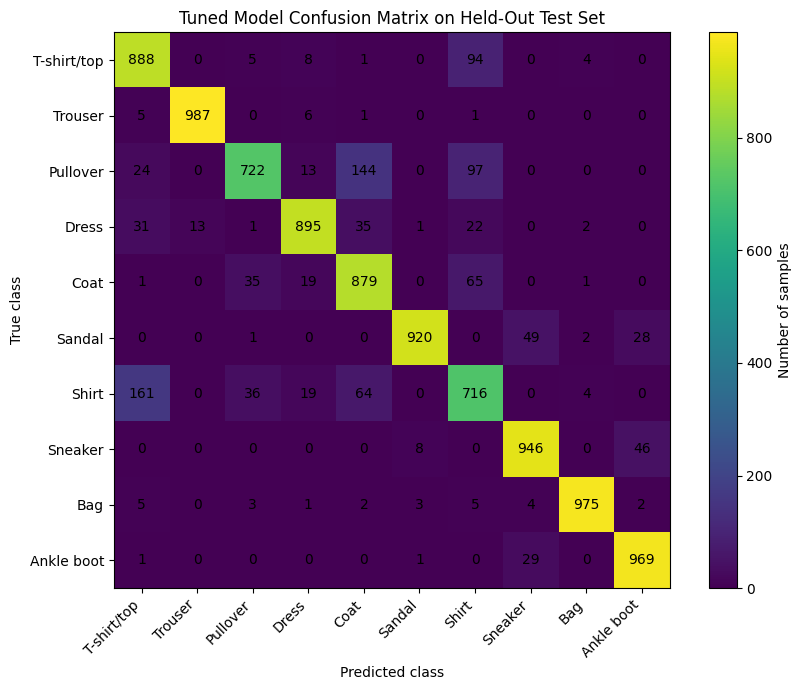

In [98]:
plt.figure(figsize=(9, 7))
plt.imshow(test_cm)
plt.xticks(np.arange(10), class_names, rotation=45, ha="right")
plt.yticks(np.arange(10), class_names)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Tuned Model Confusion Matrix on Held-Out Test Set")
for i in range(10):
    for j in range(10): plt.text(j, i, int(test_cm[i, j]), ha="center", va="center")
plt.colorbar(label="Number of samples")
plt.tight_layout(); plt.show()

**Improvement over the Part 2 baseline**

In [99]:
part2_baseline_accuracy = float(activation_results["ReLU"]["history"]["val_accuracy"][-1])
improvement_pp = (test_accuracy - part2_baseline_accuracy) * 100
print(f"Part 2 baseline (ReLU) validation accuracy: {part2_baseline_accuracy:.2%}")
print(f"Part 7 tuned model test accuracy: {test_accuracy:.2%}")
print(f"Difference: {improvement_pp:+.2f} percentage points")
if improvement_pp > 0:
    print(f"The tuned model improved over the Part 2 baseline by {improvement_pp:.2f} percentage points.")
elif improvement_pp < 0:
    print(f"The tuned model did not improve; it was lower by {abs(improvement_pp):.2f} percentage points. This can happen because CV selects the configuration with the best average training-fold validation performance, while the final held-out test set can differ from those folds. Regularisation can also trade training fit for generalisation.")
else:
    print("The tuned model matched the Part 2 baseline, so there was no improvement in percentage points.")

Part 2 baseline (ReLU) validation accuracy: 89.41%
Part 7 tuned model test accuracy: 88.97%
Difference: -0.44 percentage points
The tuned model did not improve; it was lower by 0.44 percentage points. This can happen because CV selects the configuration with the best average training-fold validation performance, while the final held-out test set can differ from those folds. Regularisation can also trade training fit for generalisation.
